# Inflation Forcasting - Notebook 1

In [ ]:
#libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Inflation Rate

In [ ]:
inflation = pd.read_csv('/content/drive/MyDrive/DSCI521-Project/Inflation /Inflation + Interest Rate EDA/T10YIEM.csv')

inflation.columns = [c.strip() for c in inflation.columns]
inflation['observation_date'] = pd.to_datetime(inflation['observation_date'], errors='coerce')


inflation = inflation[['observation_date', 'T10YIEM']].dropna().copy()
inflation = inflation.rename(columns={'observation_date': 'date', 'T10YIEM': 'inflation'})

# Quarterly mean inflation
inflation_q = (
    inflation
    .set_index('date')
    .resample('Q')['inflation']
    .mean()
    .reset_index()
)

# Year-over-year inflation rate
inflation_q['inflation_yoy'] = inflation_q['inflation'].pct_change(4) * 100

inflation_q.head(10)

/tmp/ipykernel_592/2894399418.py:14: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  .resample('Q')['inflation']


,date,inflation,inflation_yoy
0,2003-03-31,1.846667,NaN
1,2003-06-30,1.683333,NaN
2,2003-09-30,2.026667,NaN
3,2003-12-31,2.280000,NaN
4,2004-03-31,2.313333,25.270758
5,2004-06-30,2.553333,51.683168
6,2004-09-30,2.410000,18.914474
7,2004-12-31,2.480000,8.771930
8,2005-03-31,2.583333,11.671470
9,2005-06-30,2.483333,-2.741514


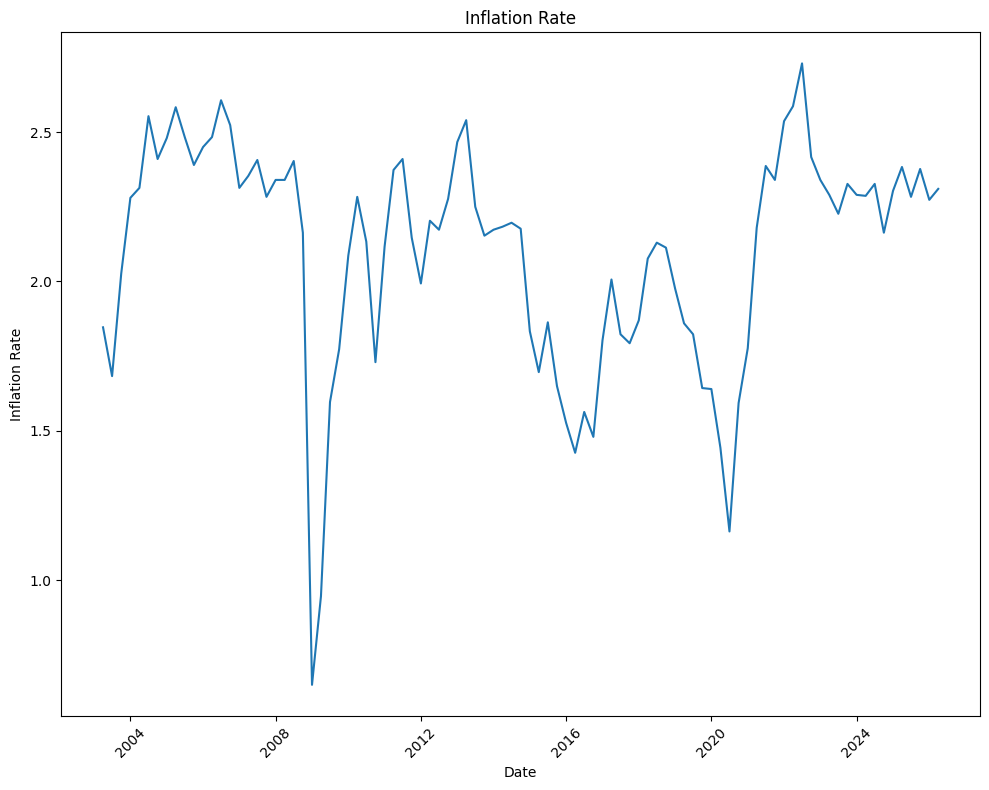

In [ ]:
plt.figure(figsize=(10, 8))
plt.plot(inflation_q['date'], inflation_q['inflation'])
plt.title('Inflation Rate')
plt.xlabel('Date')
plt.ylabel('Inflation Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### S&P 500 Daily Prices

In [ ]:
sp500 = pd.read_csv('/content/drive/MyDrive/DSCI521-Project/Inflation /Inflation + Interest Rate EDA/SP500.csv')

# Clean column names
sp500.columns = [c.strip() for c in sp500.columns]

# Convert date column
sp500['observation_date'] = pd.to_datetime(sp500['observation_date'], errors='coerce')

# Keep only needed columns
sp500 = sp500[['observation_date', 'SP500']].dropna().copy()

# Rename for consistency
sp500 = sp500.rename(columns={
    'observation_date': 'date',
    'SP500': 'sp500_price'
})

# Convert daily prices to quarterly mean
sp500_q = (
    sp500
    .set_index('date')
    .resample('Q')['sp500_price']
    .mean()
    .reset_index()
)

print(sp500_q.head())

        date  sp500_price
0 2016-03-31  2029.155556
1 2016-06-30  2075.131563
2 2016-09-30  2162.056875
3 2016-12-31  2184.878571
4 2017-03-31  2325.927903


/tmp/ipykernel_338/289799378.py:22: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  .resample('Q')['sp500_price']


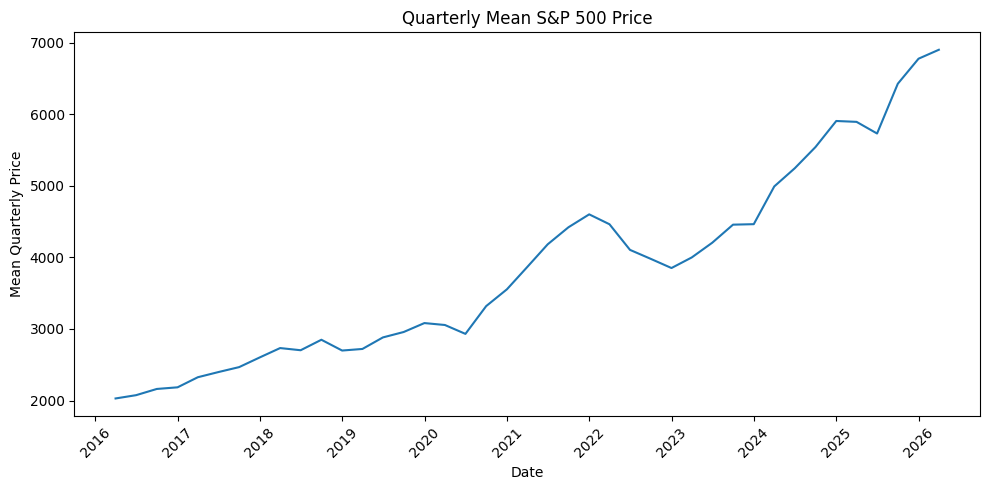

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(sp500_q['date'], sp500_q['sp500_price'])
plt.title('Quarterly Mean S&P 500 Price')
plt.xlabel('Date')
plt.ylabel('Mean Quarterly Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Unemployment Rate
In this section we work with unemployement dataset from FRED. To undrestand the trends we visuals the data, clean and create yearly and quorterly rate.
https://fred.stlouisfed.org/series/UNRATE

In [ ]:
# making the dataframe
unemployment_rate = pd.read_csv('/content/drive/MyDrive/DSCI521-Project/Inflation /Inflation + Interest Rate EDA/unemployment_rate.csv')
unemployment_rate.head()

,observation_date,UNRATE
0,1948-01-01,3.4
1,1948-02-01,3.8
2,1948-03-01,4.0
3,1948-04-01,3.9
4,1948-05-01,3.5


In [ ]:
# changing and ensuring the date format
unemployment_rate ['observation_date'] = pd.to_datetime(unemployment_rate['observation_date'], errors = 'coerce')
unemployment_rate ['year'] = unemployment_rate['observation_date'].dt.year
unemployment_rate.head()

,observation_date,UNRATE,year
0,1948-01-01,3.4,1948
1,1948-02-01,3.8,1948
2,1948-03-01,4.0,1948
3,1948-04-01,3.9,1948
4,1948-05-01,3.5,1948


In [ ]:
yearly_avg = (
    unemployment_rate
    .groupby('year')['UNRATE']
    .mean()
    .reset_index()
)
yearly_avg.head()

,year,UNRATE
0,1948,3.750000
1,1949,6.050000
2,1950,5.208333
3,1951,3.283333
4,1952,3.025000


In [ ]:
# set index first
unemployment_rate = unemployment_rate.set_index('observation_date')

# convert to quarterly
unemployment_q = (
    unemployment_rate
    .resample('Q')['UNRATE']
    .mean()
    .reset_index()
)

# filter after 1990
unemployment_q = unemployment_q[
    unemployment_q['observation_date'].dt.year >= 1990
]

unemployment_q.head()


/tmp/ipykernel_592/4050774399.py:7: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  .resample('Q')['UNRATE']


,observation_date,UNRATE
168,1990-03-31,5.300000
169,1990-06-30,5.333333
170,1990-09-30,5.700000
171,1990-12-31,6.133333
172,1991-03-31,6.600000


In [ ]:
unemployment_q = unemployment_q.rename(
    columns={
        'observation_date': 'date',
        'UNRATE': 'unemployment_rate'
    }
)

unemployment_q = unemployment_q[['date', 'unemployment_rate']].copy()
unemployment_q.head()

,date,unemployment_rate
168,1990-03-31,5.300000
169,1990-06-30,5.333333
170,1990-09-30,5.700000
171,1990-12-31,6.133333
172,1991-03-31,6.600000


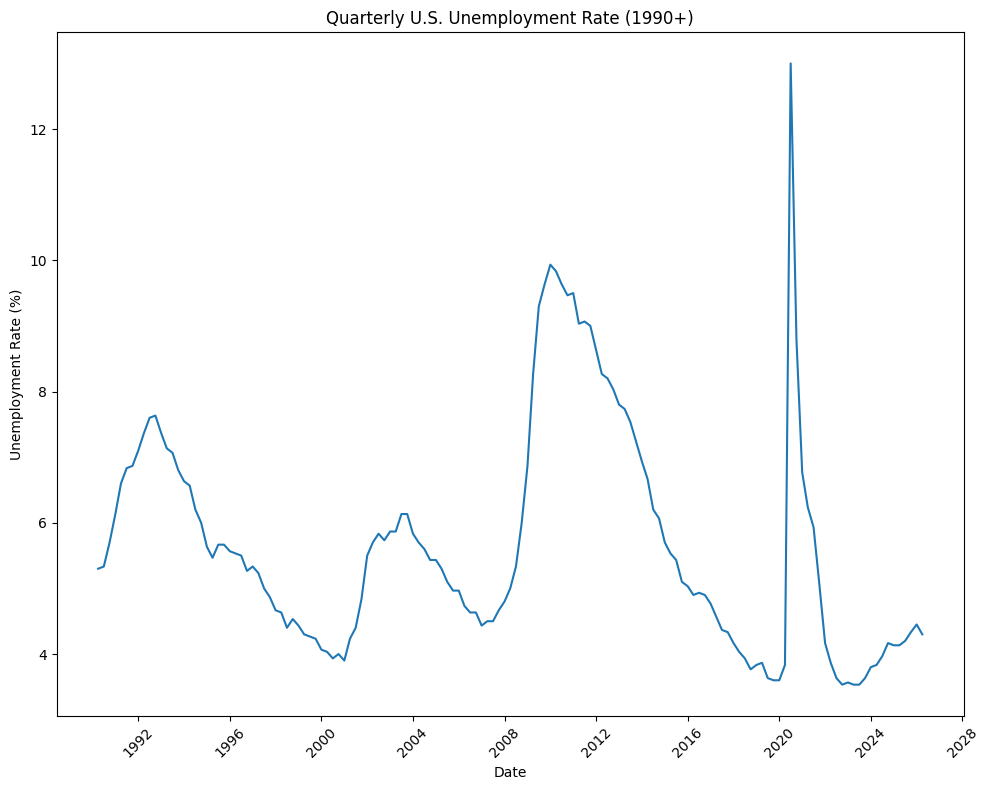

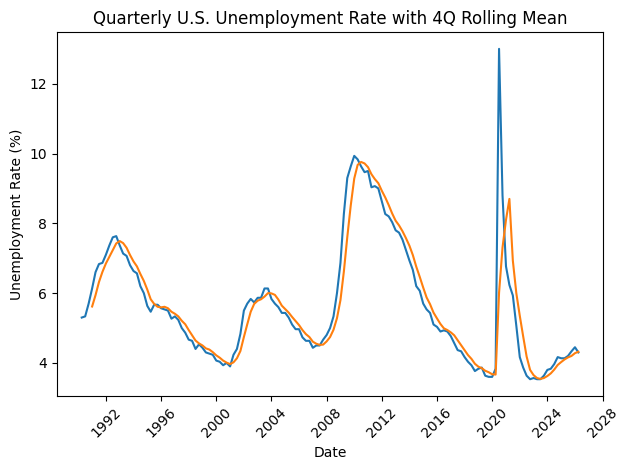

In [ ]:
# Quarterly Unemployment Line Plot
plt.figure(figsize=(10, 8))
plt.plot(unemployment_q['date'], unemployment_q['unemployment_rate'])
plt.title("Quarterly U.S. Unemployment Rate (1990+)")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Quarterly Unemployment with 4-Quarter Rolling Mean
unemployment_q['rolling_4q'] = unemployment_q['unemployment_rate'].rolling(4).mean()
plt.figure()
plt.plot(unemployment_q['date'], unemployment_q['unemployment_rate'])
plt.plot(unemployment_q['date'], unemployment_q['rolling_4q'])
plt.title("Quarterly U.S. Unemployment Rate with 4Q Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### US Dollar Index

In [ ]:
# making the dataframe
us_dollar_index = pd.read_csv('/content/drive/MyDrive/DSCI521-Project/Inflation /Inflation + Interest Rate EDA/us_dollar_index.csv')
us_dollar_index.head()

,observation_date,DTWEXBGS
0,2006-01-02,101.4155
1,2006-01-03,100.7558
2,2006-01-04,100.2288
3,2006-01-05,100.2992
4,2006-01-06,100.0241


In [ ]:
# Ensure datetime
us_dollar_index['observation_date'] = pd.to_datetime(
    us_dollar_index['observation_date'],
    errors='coerce'
)

In [ ]:
# Rename columns for merge consistency
us_dollar_index = us_dollar_index.rename(
    columns={
        'observation_date': 'date',
        'DTWEXBGS': 'usd_index'
    }
)


In [ ]:
# Sort
us_dollar_index = us_dollar_index.sort_values('date')

# Reset index
us_dollar_index = us_dollar_index.reset_index(drop=True)

us_dollar_index.head()

,date,usd_index
0,2006-01-02,101.4155
1,2006-01-03,100.7558
2,2006-01-04,100.2288
3,2006-01-05,100.2992
4,2006-01-06,100.0241


In [ ]:
# Check null values
us_dollar_index.isna().sum()

,0
date,0
usd_index,208


Since this is daily data from Federal Reserve Bank of St. Louis, those missing values are almost certainly:

* Weekends
* Federal holidays
* Market-closed days

In [ ]:
us_dollar_index = us_dollar_index.dropna()

In [ ]:
usd_q = (
    us_dollar_index
    .set_index('date')
    .resample('Q')['usd_index']
    .mean()
    .reset_index()
)
usd_q = usd_q.rename(columns={'usd_index': 'usd_index_q'})
usd_q = usd_q[['date', 'usd_index_q']].copy()
usd_q.head()

/tmp/ipykernel_338/2762818634.py:4: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  .resample('Q')['usd_index']


,date,usd_index_q
0,2006-03-31,100.216454
1,2006-06-30,98.598158
2,2006-09-30,98.034434
3,2006-12-31,97.552817
4,2007-03-31,97.439534


In [ ]:
usd_q.head()
usd_q.tail()


,date,usd_index_q
76,2025-03-31,127.644602
77,2025-06-30,122.415035
78,2025-09-30,120.237222
79,2025-12-31,120.748735
80,2026-03-31,118.689097


In [ ]:
# Sanity check NA values
usd_q.isna().sum()


,0
date,0
usd_index_q,0


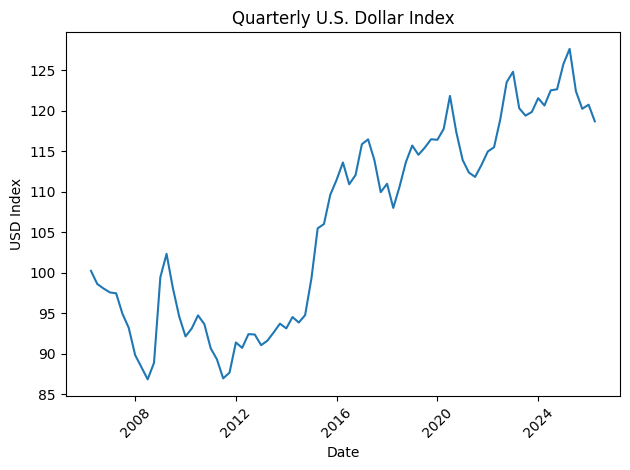

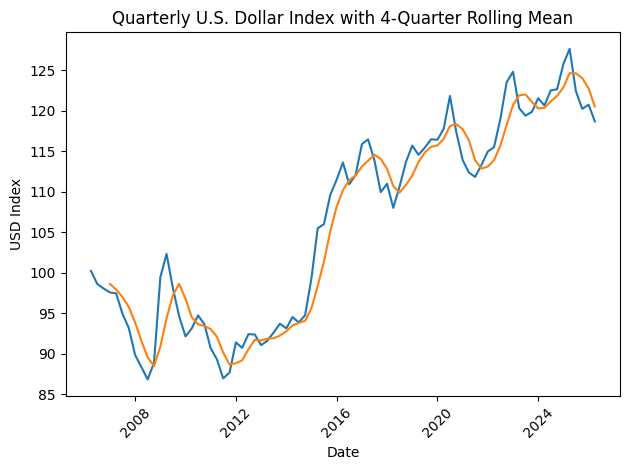

In [ ]:
# Quarterly USD Index
plt.figure()
plt.plot(usd_q['date'], usd_q['usd_index_q'])
plt.title("Quarterly U.S. Dollar Index")
plt.xlabel("Date")
plt.ylabel("USD Index")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Quarterly USD Index with 4-Quarter Rolling Mean
usd_q['rolling_4q'] = usd_q['usd_index_q'].rolling(4).mean()
plt.figure()
plt.plot(usd_q['date'], usd_q['usd_index_q'])
plt.plot(usd_q['date'], usd_q['rolling_4q'])
plt.title("Quarterly U.S. Dollar Index with 4-Quarter Rolling Mean")
plt.xlabel("Date")
plt.ylabel("USD Index")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


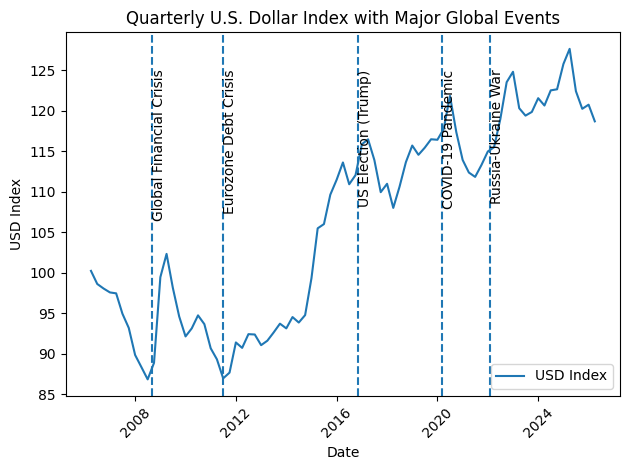

In [ ]:
plt.figure()

# Plot USD Index
plt.plot(usd_q['date'], usd_q['usd_index_q'], label="USD Index")

# Major global macro events (approximate dates)
events = {
    "Global Financial Crisis": "2008-09-01",
    "Eurozone Debt Crisis": "2011-07-01",
    "US Election (Trump)": "2016-11-01",
    "COVID-19 Pandemic": "2020-03-01",
    "Russia-Ukraine War": "2022-02-01"
}

for label, date in events.items():
    plt.axvline(pd.to_datetime(date), linestyle='--')
    plt.text(pd.to_datetime(date),
             usd_q['usd_index_q'].max()*0.98,
             label,
             rotation=90,
             verticalalignment='top')

plt.title("Quarterly U.S. Dollar Index with Major Global Events")
plt.xlabel("Date")
plt.ylabel("USD Index")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


### Oil Price

In [ ]:
# load daily crude oil prices
oil_price = pd.read_excel('/content/drive/MyDrive/DSCI521-Project/Inflation /Inflation + Interest Rate EDA/oil_price.xls', sheet_name='Data 1',skiprows=2)
oil_price.columns = ["Date", "OK WTI Spot Price", "Brent Spot Price"]
oil_price.head()

,Date,OK WTI Spot Price,Brent Spot Price
0,1986-01-02,25.56,NaN
1,1986-01-03,26.00,NaN
2,1986-01-06,26.53,NaN
3,1986-01-07,25.85,NaN
4,1986-01-08,25.87,NaN


In [ ]:
#Filtering the data on dates after 1990
oil_price = oil_price[oil_price['Date'].dt.year >= 1990]

oil_price.head()

,Date,OK WTI Spot Price,Brent Spot Price
1022,1990-01-02,22.88,21.20
1023,1990-01-03,23.81,22.65
1024,1990-01-04,23.41,22.50
1025,1990-01-05,23.07,23.13
1026,1990-01-08,21.64,21.38


In [ ]:
oil_price.isna().sum()

,0
Date,0
OK WTI Spot Price,172
Brent Spot Price,90


In [ ]:
oil_price.dropna(inplace=True)

In [ ]:
# oil price to quorterly mean
oil_price['Date'] = pd.to_datetime(oil_price['Date'], errors='coerce')

# Pick one oil series
oil_q = (
    oil_price[['Date', 'Brent Spot Price']]
    .dropna()
    .rename(columns={'Date': 'date', 'Brent Spot Price': 'brent_oil'})
    .set_index('date')
    .resample('Q')['brent_oil']
    .mean()
    .reset_index()
)

oil_q.head()

/tmp/ipykernel_338/1855849112.py:10: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  .resample('Q')['brent_oil']


,date,brent_oil
0,1990-03-31,19.817656
1,1990-06-30,16.009355
2,1990-09-30,26.162308
3,1990-12-31,32.638000
4,1991-03-31,20.819839


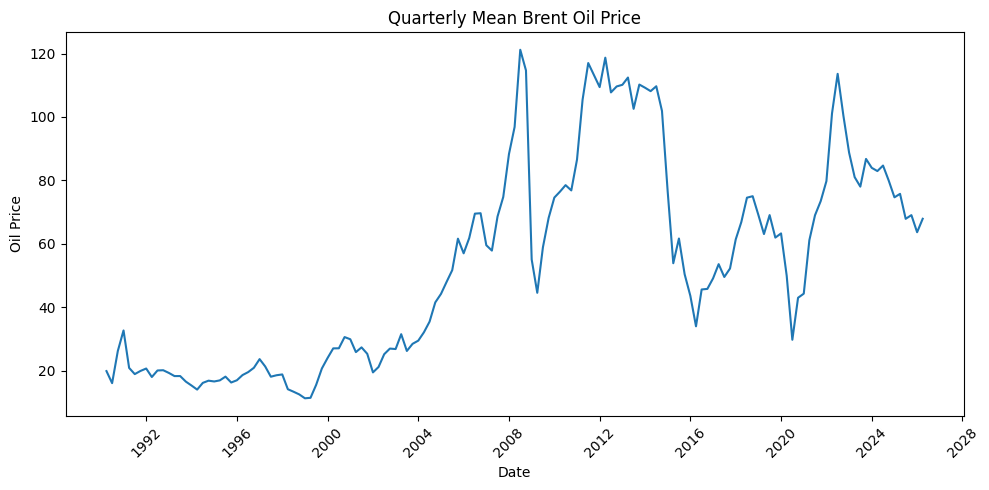

In [ ]:
# checking the tred of the dataset
plt.figure(figsize=(10, 5))
plt.plot(oil_q['date'], oil_q['brent_oil'])
plt.title('Quarterly Mean Brent Oil Price')
plt.xlabel('Date')
plt.ylabel('Oil Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# load daily crude oil prices
oil_price_new = pd.read_excel('/content/drive/MyDrive/DSCI521-Project/Inflation /Inflation + Interest Rate EDA/oil_prices_NEW.xls', sheet_name='Data 1',skiprows=2)
oil_price_new.columns = ["Date", "OK WTI Spot Price", "Brent Spot Price"]
oil_price_new = oil_price_new[oil_price_new['Date'].dt.year >= 2026]
oil_price_new.head()

,Date,OK WTI Spot Price,Brent Spot Price
10242,2026-01-02,57.21,61.98
10243,2026-01-05,58.10,63.00
10244,2026-01-06,56.97,62.10
10245,2026-01-07,56.01,61.08
10246,2026-01-08,57.74,63.34


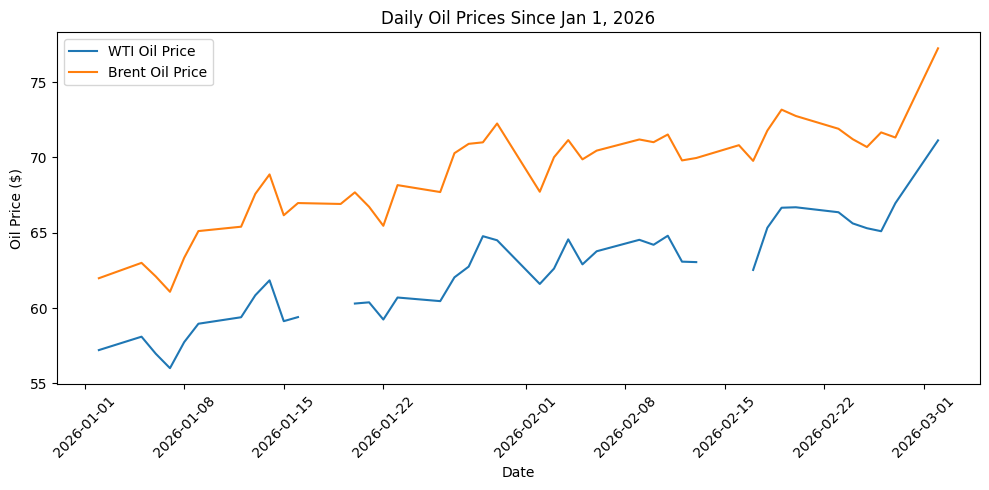

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(oil_price_new['Date'], oil_price_new['OK WTI Spot Price'], label='WTI Oil Price')
plt.plot(oil_price_new['Date'], oil_price_new['Brent Spot Price'], label='Brent Oil Price')

plt.title('Daily Oil Prices Since Jan 1, 2026')
plt.xlabel('Date')
plt.ylabel('Oil Price ($)')
plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

### Merging the data and creating the model

In [ ]:
df = inflation_q.merge(unemployment_q, on='date', how='left')
df = df.merge(usd_q, on='date', how='left')
df = df.merge(oil_q, on='date', how='left')
df = df.merge(sp500_q, on='date', how='left')

df = df.sort_values('date').reset_index(drop=True)
df.head()

,date,inflation,inflation_yoy,unemployment_rate,rolling_4q_x,usd_index_q,rolling_4q_y,brent_oil,sp500_price
0,2003-03-31,1.846667,NaN,5.866667,5.825000,NaN,NaN,31.459508,NaN
1,2003-06-30,1.683333,NaN,6.133333,5.900000,NaN,NaN,26.167143,NaN
2,2003-09-30,2.026667,NaN,6.133333,6.000000,NaN,NaN,28.414531,NaN
3,2003-12-31,2.280000,NaN,5.833333,5.991667,NaN,NaN,29.421452,NaN
4,2004-03-31,2.313333,25.270758,5.700000,5.950000,NaN,NaN,32.055082,NaN


In [ ]:
# Rename ambiguous rolling columns
df = df.rename(columns={
    'rolling_4q_x': 'unemployment_rolling_4q',
    'rolling_4q_y': 'usd_rolling_4q'
})

print(df.columns.tolist())

['date', 'inflation', 'inflation_yoy', 'unemployment_rate', 'unemployment_rolling_4q', 'usd_index_q', 'usd_rolling_4q', 'brent_oil', 'sp500_price']


In [ ]:
# FEATURE ENGINEERING

# Quarter-over-quarter percent changes for market variables
df['sp500_return_qoq'] = df['sp500_price'].pct_change(1) * 100
df['oil_return_qoq'] = df['brent_oil'].pct_change(1) * 100
df['usd_return_qoq'] = df['usd_index_q'].pct_change(1) * 100

# Create lag features
lag_base_cols = [
    'inflation_yoy',
    'unemployment_rate',
    'unemployment_rolling_4q'
]

lag_full_cols = [
    'usd_index_q',
    'usd_return_qoq',
    'usd_rolling_4q',
    'brent_oil',
    'oil_return_qoq',
    'sp500_price',
    'sp500_return_qoq'
]

# Lags for macro-only model
for col in lag_base_cols:
    for lag in [1, 2, 4]:
        df[f'{col}_lag{lag}'] = df[col].shift(lag)

# Lags for full model
for col in lag_full_cols:
    for lag in [1, 2, 4]:
        df[f'{col}_lag{lag}'] = df[col].shift(lag)

# Target = next quarter inflation
df['target_next_q_inflation'] = df['inflation_yoy'].shift(-1)

print(df[['date', 'inflation_yoy', 'target_next_q_inflation']].head(10))

        date  inflation_yoy  target_next_q_inflation
0 2003-03-31            NaN                      NaN
1 2003-06-30            NaN                      NaN
2 2003-09-30            NaN                      NaN
3 2003-12-31            NaN                25.270758
4 2004-03-31      25.270758                51.683168
5 2004-06-30      51.683168                18.914474
6 2004-09-30      18.914474                 8.771930
7 2004-12-31       8.771930                11.671470
8 2005-03-31      11.671470                -2.741514
9 2005-06-30      -2.741514                -0.829876


In [ ]:
#DATASET A: MACRO ONLY (longer history)
base_features = [
    'inflation_yoy_lag1',
    'inflation_yoy_lag2',
    'inflation_yoy_lag4',
    'unemployment_rate_lag1',
    'unemployment_rate_lag2',
    'unemployment_rate_lag4',
    'unemployment_rolling_4q_lag1',
    'unemployment_rolling_4q_lag2',
    'unemployment_rolling_4q_lag4'
]

base_model_df = df[['date', 'target_next_q_inflation'] + base_features].dropna().copy()

print("Base model shape:", base_model_df.shape)
print(base_model_df.head())

Base model shape: (84, 11)
         date  target_next_q_inflation  inflation_yoy_lag1  \
8  2005-03-31                -2.741514            8.771930   
9  2005-06-30                -0.829876           11.671470   
10 2005-09-30                -1.209677           -2.741514   
11 2005-12-31                -3.870968           -0.829876   
12 2006-03-31                 4.966443           -1.209677   

    inflation_yoy_lag2  inflation_yoy_lag4  unemployment_rate_lag1  \
8            18.914474           25.270758                5.433333   
9             8.771930           51.683168                5.300000   
10           11.671470           18.914474                5.100000   
11           -2.741514            8.771930                4.966667   
12           -0.829876           11.671470                4.966667   

    unemployment_rate_lag2  unemployment_rate_lag4  \
8                 5.433333                5.700000   
9                 5.433333                5.600000   
10               

In [ ]:
# DATASET B: MACRO + MARKET
full_features = base_features + [
    'usd_index_q_lag1',
    'usd_index_q_lag2',
    'usd_index_q_lag4',
    'usd_return_qoq_lag1',
    'usd_return_qoq_lag2',
    'usd_return_qoq_lag4',
    'usd_rolling_4q_lag1',
    'usd_rolling_4q_lag2',
    'usd_rolling_4q_lag4',
    'brent_oil_lag1',
    'brent_oil_lag2',
    'brent_oil_lag4',
    'oil_return_qoq_lag1',
    'oil_return_qoq_lag2',
    'oil_return_qoq_lag4',
    'sp500_price_lag1',
    'sp500_price_lag2',
    'sp500_price_lag4',
    'sp500_return_qoq_lag1',
    'sp500_return_qoq_lag2',
    'sp500_return_qoq_lag4'
]

full_model_df = df[['date', 'target_next_q_inflation'] + full_features].dropna().copy()

print("Full model shape:", full_model_df.shape)
print(full_model_df.head())

Full model shape: (35, 32)
         date  target_next_q_inflation  inflation_yoy_lag1  \
57 2017-06-30                21.171171           40.654206   
58 2017-09-30                 3.696858           16.631130   
59 2017-12-31                 3.488372           21.171171   
60 2018-03-31                16.819013            3.696858   
61 2018-06-30                17.843866            3.488372   

    inflation_yoy_lag2  inflation_yoy_lag4  unemployment_rate_lag1  \
57           18.122271          -16.100179                4.566667   
58           40.654206          -10.303030                4.366667   
59           16.631130           18.122271                4.333333   
60           21.171171           40.654206                4.166667   
61            3.696858           16.631130                4.033333   

    unemployment_rate_lag2  unemployment_rate_lag4  \
57                4.766667                4.933333   
58                4.566667                4.900000   
59               

In [ ]:
# TIME SERIES TRAIN/TEST SPLIT
def time_split(model_df, feature_cols, target_col='target_next_q_inflation', train_size=0.8):
    model_df = model_df.sort_values('date').reset_index(drop=True)

    X = model_df[feature_cols]
    y = model_df[target_col]
    dates = model_df['date']

    split_idx = int(len(model_df) * train_size)

    X_train = X.iloc[:split_idx]
    X_test = X.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]
    dates_train = dates.iloc[:split_idx]
    dates_test = dates.iloc[split_idx:]

    return X_train, X_test, y_train, y_test, dates_train, dates_test

In [ ]:
# BASELINE MODEL FUNCTION
def run_linear_regression(model_df, feature_cols, model_name="Model"):
    X_train, X_test, y_train, y_test, dates_train, dates_test = time_split(model_df, feature_cols)

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"\n{model_name} - Linear Regression")
    print("Train size:", len(X_train))
    print("Test size:", len(X_test))
    print("MAE :", round(mae, 4))
    print("RMSE:", round(rmse, 4))
    print("R^2 :", round(r2, 4))

    results = pd.DataFrame({
        'date': dates_test,
        'actual': y_test.values,
        'predicted': y_pred
    })

    return model, results, {'MAE': mae, 'RMSE': rmse, 'R2': r2}

In [ ]:
# RANDOM FOREST MODEL FUNCTION

def run_random_forest(model_df, feature_cols, model_name="Model"):
    X_train, X_test, y_train, y_test, dates_train, dates_test = time_split(model_df, feature_cols)

    model = RandomForestRegressor(
        n_estimators=300,
        max_depth=6,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=42
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"\n{model_name} - Random Forest")
    print("Train size:", len(X_train))
    print("Test size:", len(X_test))
    print("MAE :", round(mae, 4))
    print("RMSE:", round(rmse, 4))
    print("R^2 :", round(r2, 4))

    results = pd.DataFrame({
        'date': dates_test,
        'actual': y_test.values,
        'predicted': y_pred
    })

    return model, results, {'MAE': mae, 'RMSE': rmse, 'R2': r2}

In [ ]:
# RUN MODELS - DATASET A
lr_base_model, lr_base_results, lr_base_metrics = run_linear_regression(
    base_model_df,
    base_features,
    model_name="Base Dataset"
)

rf_base_model, rf_base_results, rf_base_metrics = run_random_forest(
    base_model_df,
    base_features,
    model_name="Base Dataset"
)


Base Dataset - Linear Regression
Train size: 67
Test size: 17
MAE : 24.3057
RMSE: 39.3024
R^2 : -18.9675

Base Dataset - Random Forest
Train size: 67
Test size: 17
MAE : 8.4845
RMSE: 10.5447
R^2 : -0.4373


In [ ]:
# RUN MODELS - DATASET B
lr_full_model, lr_full_results, lr_full_metrics = run_linear_regression(
    full_model_df,
    full_features,
    model_name="Full Dataset"
)

rf_full_model, rf_full_results, rf_full_metrics = run_random_forest(
    full_model_df,
    full_features,
    model_name="Full Dataset"
)


Full Dataset - Linear Regression
Train size: 28
Test size: 7
MAE : 51.2371
RMSE: 62.8167
R^2 : -153.2364

Full Dataset - Random Forest
Train size: 28
Test size: 7
MAE : 9.2683
RMSE: 11.2032
R^2 : -3.9059


In [ ]:
# MODEL COMPARISON TABLE
comparison = pd.DataFrame([
    ['Base Dataset', 'Linear Regression', lr_base_metrics['MAE'], lr_base_metrics['RMSE'], lr_base_metrics['R2']],
    ['Base Dataset', 'Random Forest', rf_base_metrics['MAE'], rf_base_metrics['RMSE'], rf_base_metrics['R2']],
    ['Full Dataset', 'Linear Regression', lr_full_metrics['MAE'], lr_full_metrics['RMSE'], lr_full_metrics['R2']],
    ['Full Dataset', 'Random Forest', rf_full_metrics['MAE'], rf_full_metrics['RMSE'], rf_full_metrics['R2']],
], columns=['Dataset', 'Model', 'MAE', 'RMSE', 'R2'])

comparison = comparison.sort_values(by='RMSE')
print(comparison)

        Dataset              Model        MAE       RMSE          R2
1  Base Dataset      Random Forest   8.484480  10.544660   -0.437314
3  Full Dataset      Random Forest   9.268274  11.203206   -3.905929
0  Base Dataset  Linear Regression  24.305660  39.302375  -18.967520
2  Full Dataset  Linear Regression  51.237094  62.816701 -153.236412


Random Forest clearly outperforms Linear Regression and the base dataset performs slightly better.

In [ ]:
import matplotlib.pyplot as plt

def plot_predictions(results_df, title):
    plt.figure(figsize=(11, 5))
    plt.plot(results_df['date'], results_df['actual'], label='Actual')
    plt.plot(results_df['date'], results_df['predicted'], label='Predicted')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Next Quarter Inflation YoY (%)')
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

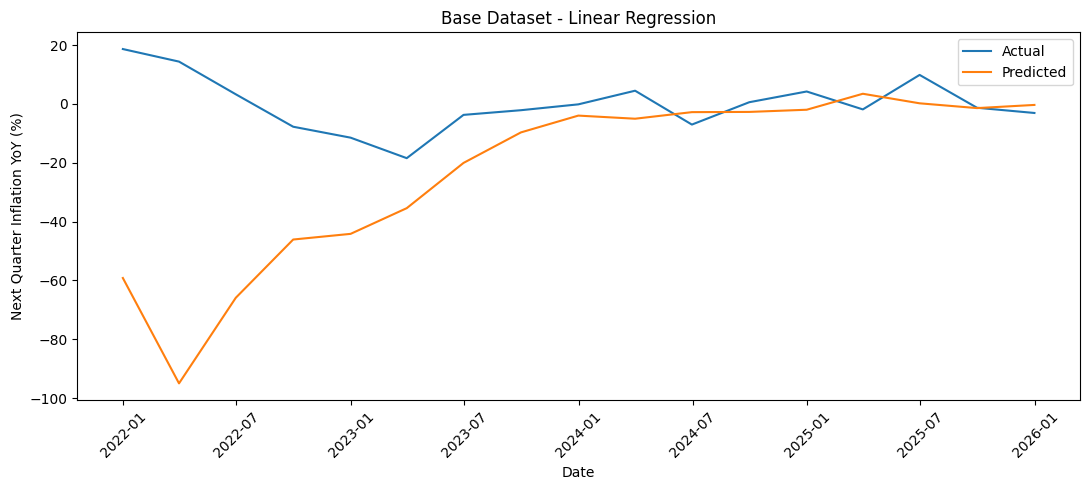

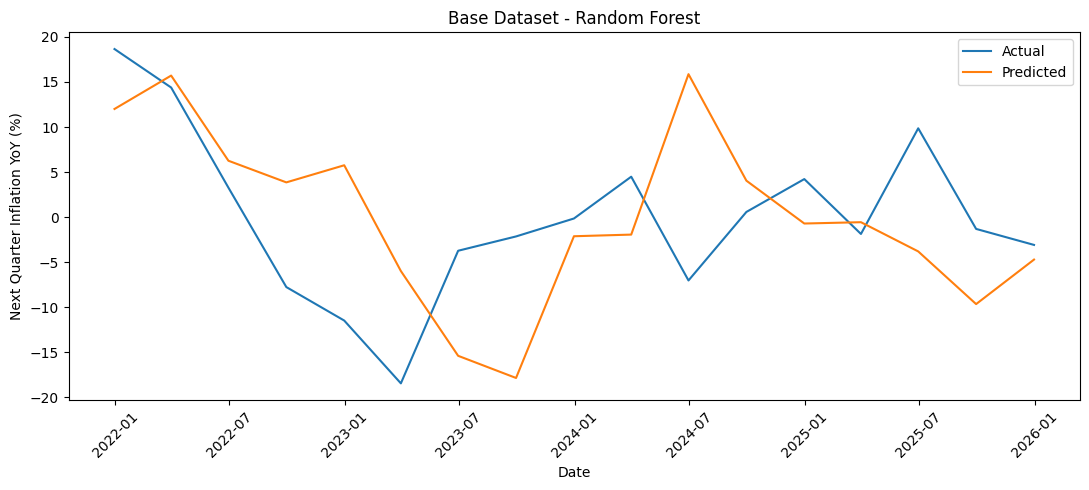

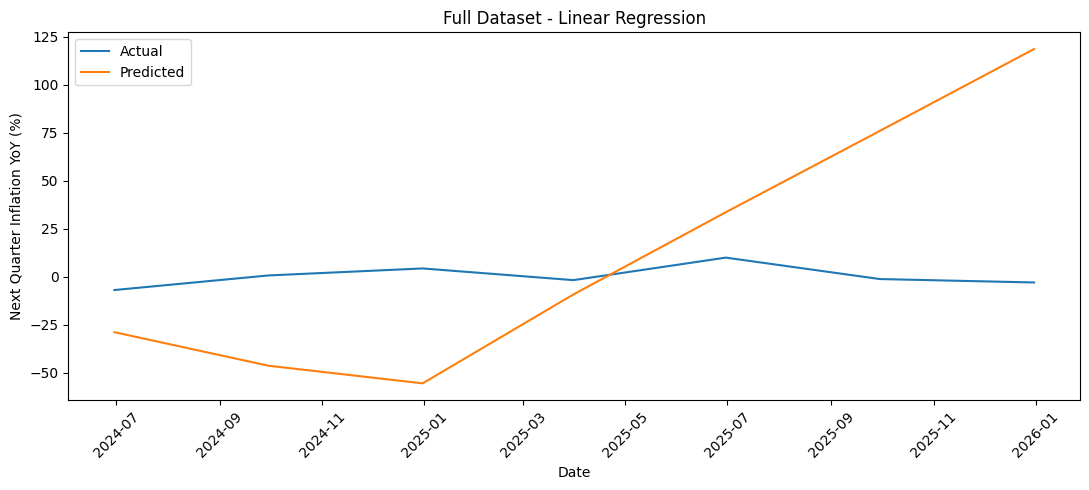

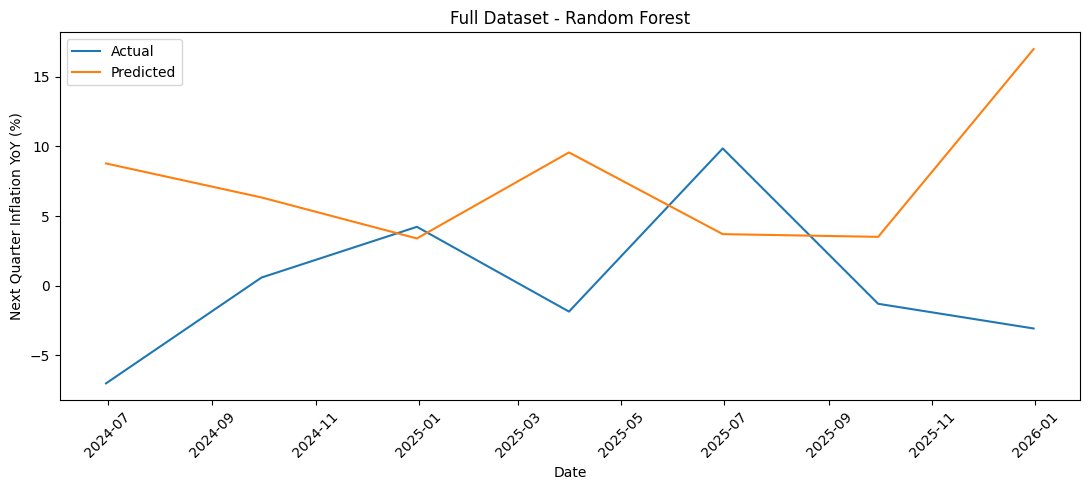

In [ ]:
plot_predictions(lr_base_results, 'Base Dataset - Linear Regression')
plot_predictions(rf_base_results, 'Base Dataset - Random Forest')
plot_predictions(lr_full_results, 'Full Dataset - Linear Regression')
plot_predictions(rf_full_results, 'Full Dataset - Random Forest')

Base Dataset — Random Forest:
* The model captures direction of change reasonably well
* It sometimes overshoots or lags turning points
* Predictions remain within a realistic range

Linear Regression Graphs:

* The model tries to fit a straight relationship
* Economic variables interact nonlinearly
* Multicollinearity likely exists between features

In [ ]:
# FEATURE IMPORTANCE
importances = pd.DataFrame({
    'feature': full_features,
    'importance': rf_full_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importances.head(15))

                         feature  importance
6   unemployment_rolling_4q_lag1    0.201493
3         unemployment_rate_lag1    0.170124
4         unemployment_rate_lag2    0.158229
27         sp500_return_qoq_lag1    0.136707
7   unemployment_rolling_4q_lag2    0.068574
19                brent_oil_lag2    0.062011
28         sp500_return_qoq_lag2    0.027606
17           usd_rolling_4q_lag4    0.025096
22           oil_return_qoq_lag2    0.016400
20                brent_oil_lag4    0.013310
18                brent_oil_lag1    0.013287
21           oil_return_qoq_lag1    0.012311
5         unemployment_rate_lag4    0.010297
24              sp500_price_lag1    0.008941
12           usd_return_qoq_lag1    0.007293


Unemployment dominates inflation prediction which aligns with Phillips curve theory. Key points are:

* Inflation and unemployment are linked.
* Lower unemployment → higher wage pressure → higher inflation.
* Your model is detecting exactly that relationship.

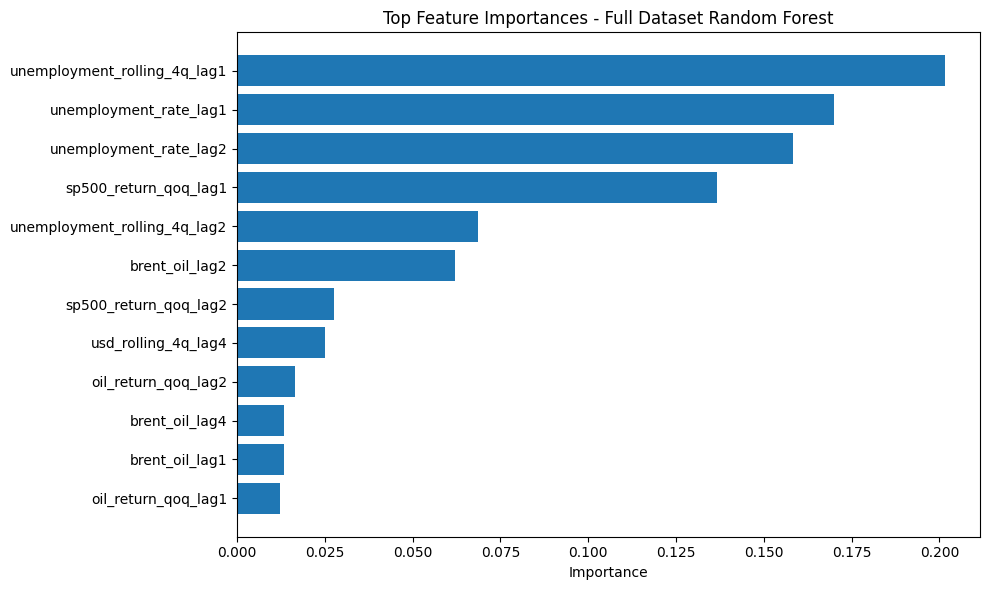

In [ ]:
plt.figure(figsize=(10, 6))
top_n = 12
top_importances = importances.head(top_n)

plt.barh(top_importances['feature'], top_importances['importance'])
plt.gca().invert_yaxis()
plt.title('Top Feature Importances - Full Dataset Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [ ]:
# NEXT QUARTER FORECAST
latest_full_features = full_model_df[full_features].iloc[[-1]]
next_q_prediction = rf_full_model.predict(latest_full_features)[0]

print("Predicted next quarter inflation YoY (%):", round(next_q_prediction, 3))

Predicted next quarter inflation YoY (%): 17.002


In [ ]:
latest_base_features = base_model_df[base_features].iloc[[-1]]
next_q_prediction_base = rf_base_model.predict(latest_base_features)[0]

print("Predicted next quarter inflation YoY (%):", round(next_q_prediction_base, 3))

Predicted next quarter inflation YoY (%): -4.704


Model Comparison

Two models were evaluated for predicting next-quarter inflation: Linear Regression and Random Forest. Random Forest significantly outperformed Linear Regression across all evaluation metrics. Linear regression produced unstable predictions due to the nonlinear relationships between macroeconomic variables.

Dataset Comparison

Two datasets were constructed: a base macroeconomic dataset using inflation and unemployment indicators, and an extended dataset including financial market variables such as oil prices, the S&P 500 index, and the USD index. The base dataset slightly outperformed the extended dataset, suggesting that additional financial indicators did not substantially improve predictive accuracy in this model.

Feature Importance

Feature importance analysis from the Random Forest model indicates that unemployment-related variables are the strongest predictors of inflation. This finding aligns with the Phillips Curve framework, which suggests a relationship between unemployment and inflation. Financial variables such as S&P 500 returns and oil prices showed moderate predictive influence but were less important than labor market indicators.

Limitations

The predictive performance is limited by the relatively small dataset and the inherent difficulty of forecasting macroeconomic variables. Inflation is influenced by complex global economic factors, policy decisions, and unexpected shocks that may not be fully captured by historical indicators.